# 13 · One Universal Clock Law — Not a Model per Stock

A fair question: if we fit a model to each of 100 stocks, have we found a *law*, or just
100 descriptions? A law must be the **same object for every stock** — like the AND-gate
formula, identical for every AND gate. So we test for **universality** the way physics
does: with a **data collapse**.

The idea in one line: a stock's turns-per-year depends on its own volatility — that is
mere **scale**, not physics. Remove it (rescale each stock's gaps by their own mean) and
ask whether all 100 distributions fall on **one curve**. What is universal is the *shape*
and the *exponent*; what is per-stock is a single scale number.

The honest result, stated up front:

* The gap distribution **is universal** — one lognormal shape for all 100 stocks, with
  per-stock scale the only free number. **One law, not a hundred.**
* **But** that shape is a *marginal* property: a shuffled market has the *same* one, so
  the distribution's shape is not where the structure lives.
* The genuinely **structural** universal constant is the **self-similarity exponent
  α ≈ ½** — tight across stocks, and absent from the shuffle. That is the law the shuffle
  cannot fake.

In [1]:
# --- Run me first: make this notebook executable from anywhere -----------------
import os, sys

def _find_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "PROTOCOL_order_discovery.md")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    for cand in [os.path.expanduser("~/Documents/projects/CausalBool/index-deconvolution")]:
        if os.path.isfile(os.path.join(cand, "PROTOCOL_order_discovery.md")):
            return cand
    raise RuntimeError("Could not locate the index-deconvolution root. "
                       "Set ROOT = '/path/to/index-deconvolution' by hand and re-run.")

ROOT = _find_root()
for _sub in ["src", "level2", "level3", "level4", "level5", "level6", "level7", "level8"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA       = os.path.join(ROOT, "finance", "data")          # 23 tickers, 3 years
DATA_LONG  = os.path.join(ROOT, "finance", "data_long")     # 12 instruments, ~30+ years
BIO        = os.path.join(os.path.dirname(ROOT), "data", "bio", "raw")  # .bnet networks

import matplotlib.pyplot as plt
import numpy as np

# a clean, consistent didactic style
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "image.cmap": "magma",
})
INK, HL, OK, BAD = "#20222b", "#c1121f", "#2a9d8f", "#e07a1f"
print("repo root :", ROOT)
print("ready. matplotlib + numpy loaded; code layers on the path.")

repo root : /Users/alberto/Documents/projects/CausalBool/index-deconvolution
ready. matplotlib + numpy loaded; code layers on the path.


In [2]:
for _sub in ["level6", "level17"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)
import json
DATA_100 = os.path.join(ROOT, "finance", "data_100")
from finance import load_yahoo_close

def load_stock(t):
    px = load_yahoo_close(os.path.join(DATA_100, t + ".json"))
    return [px[d] for d in sorted(px)]

with open(os.path.join(ROOT, "results", "exp39_universal_collapse.json")) as _f:
    R = json.load(_f)
print("panel:", R["n_series"], "stocks")

panel: 100 stocks


## Part 1 · The collapse — 100 stocks onto one curve

Left: the raw gap distributions of all 100 stocks (each a faint line). Right: the same
after dividing each stock's gaps by its own mean. The per-stock scale (mean gap 4–9 days)
is the only thing that differed; once removed, the curves lie on top of each other.

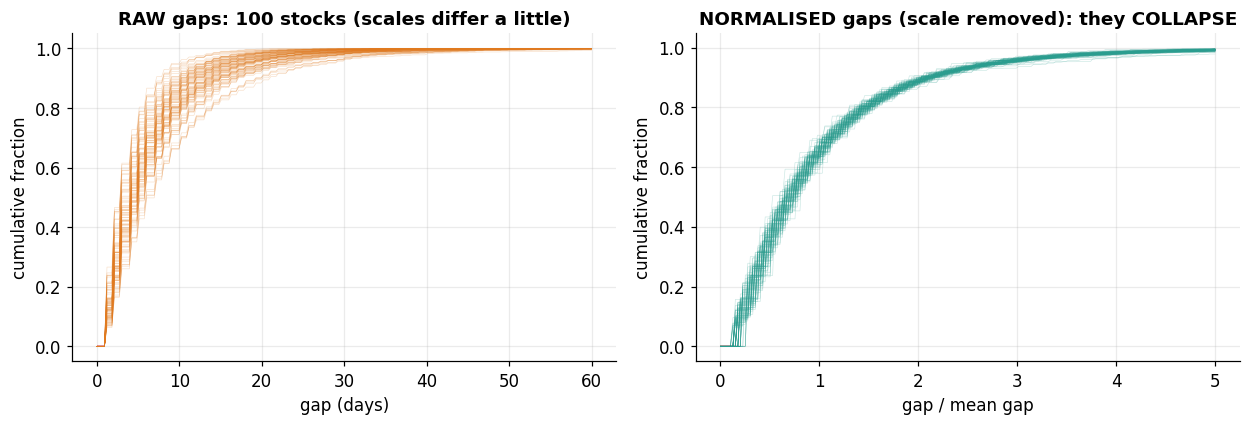

collapse KS to the pooled curve: normalised mean 0.095 (max 0.154); per-stock scale = mean gap 4..9 days.


In [3]:
from point_process import pivot_indices
from scaling import gaps_of, normalised_gaps
import numpy as np
theta = R["theta"]
names = [r for r in [row for row in []]]  # placeholder
stocks = [r["name"] if isinstance(r, dict) else r for r in []]

# recompute per-stock gap distributions live (cheap)
import os as _os
tickers = [f[:-5] for f in sorted(_os.listdir(DATA_100)) if f.endswith(".json")]
raw, norm = [], []
for tk in tickers:
    try:
        s = load_stock(tk)
    except Exception:
        continue
    ev = pivot_indices(s, theta)
    if len(ev) < 60: continue
    g = gaps_of(ev)
    raw.append(g); norm.append(normalised_gaps(ev))

def cdf(sample, grid):
    s = np.sort(sample); return np.searchsorted(s, grid, side="right")/len(s)

fig, (ax, bx) = plt.subplots(1, 2, figsize=(11.5, 4))
gr = np.linspace(0, 60, 200)
for g in raw:
    ax.plot(gr, cdf(g, gr), color=BAD, lw=0.4, alpha=0.25)
ax.set_title(f"RAW gaps: {len(raw)} stocks (scales differ a little)")
ax.set_xlabel("gap (days)"); ax.set_ylabel("cumulative fraction")
gn = np.linspace(0, 5, 200)
for g in norm:
    bx.plot(gn, cdf(g, gn), color=OK, lw=0.4, alpha=0.25)
bx.set_title("NORMALISED gaps (scale removed): they COLLAPSE")
bx.set_xlabel("gap / mean gap"); bx.set_ylabel("cumulative fraction")
plt.tight_layout(); plt.show()
c = R["collapse"]
print(f"collapse KS to the pooled curve: normalised mean {c['normalised_mean_ks']:.3f} "
      f"(max {c['normalised_max_ks']:.3f}); per-stock scale = mean gap "
      f"{R['scale']['mean_gap_min']:.0f}..{R['scale']['mean_gap_max']:.0f} days.")

## Part 2 · The universal shape — real, but a *marginal* one

The pooled, collapsed gaps follow a single **lognormal** law. But here is the honest
catch: a shuffled market — same gap sizes, time order destroyed — collapses onto the
**same** lognormal. So the *shape* of the gap distribution is universal but it is a
property of the sizes alone, not of the temporal structure. The two curves sit almost on
top of each other.

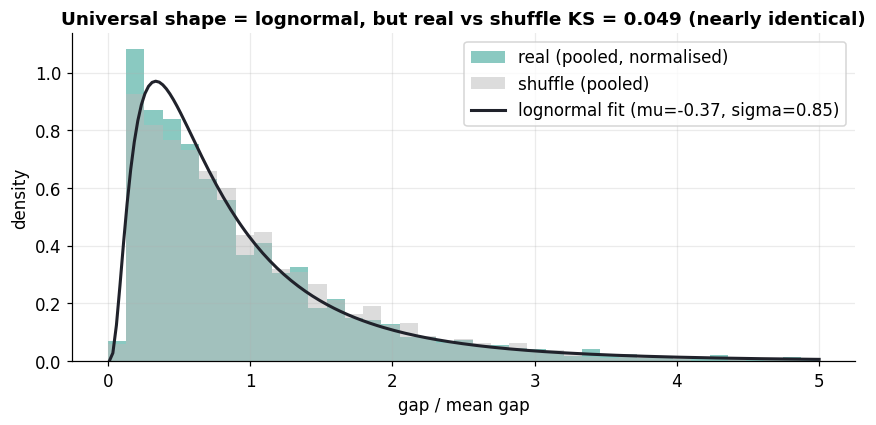

The gap-size shape is universal AND shuffle-shared -> a marginal property, not the structure.


In [4]:
import math
pooled = np.array(R["pooled_sample"]); pooled_sh = np.array(R["pooled_shuffle_sample"])
u = R["universal_law"]; p = u["real_params"]
gr = np.linspace(0.01, 5, 200)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pooled, bins=np.linspace(0,5,40), density=True, color=OK, alpha=0.55, label="real (pooled, normalised)")
ax.hist(pooled_sh, bins=np.linspace(0,5,40), density=True, color="#bbb", alpha=0.5, label="shuffle (pooled)")
if u["real"] == "lognormal":
    mu, sig = p["mu"], p["sigma"]
    pdf = [ (1/(x*sig*math.sqrt(2*math.pi)))*math.exp(-(math.log(x)-mu)**2/(2*sig*sig)) for x in gr ]
    ax.plot(gr, pdf, color=INK, lw=2, label=f"lognormal fit (mu={mu:.2f}, sigma={sig:.2f})")
ax.set_xlabel("gap / mean gap"); ax.set_ylabel("density"); ax.legend()
ax.set_title(f"Universal shape = {u['real']}, but real vs shuffle KS = {u['ks_real_vs_shuffle']:.3f} (nearly identical)")
plt.tight_layout(); plt.show()
print("The gap-size shape is universal AND shuffle-shared -> a marginal property, not the structure.")

## Part 3 · The universal *structural* constant — the exponent α

Where the shuffle and the market truly part is the **self-similarity exponent** α (how
the burstiness grows across time-scales). It is tight across the 100 stocks — one value,
a universal exponent near **½** at fine scales — and the shuffle has none of it. This is
the law: not a per-stock parameter, a market-wide constant.

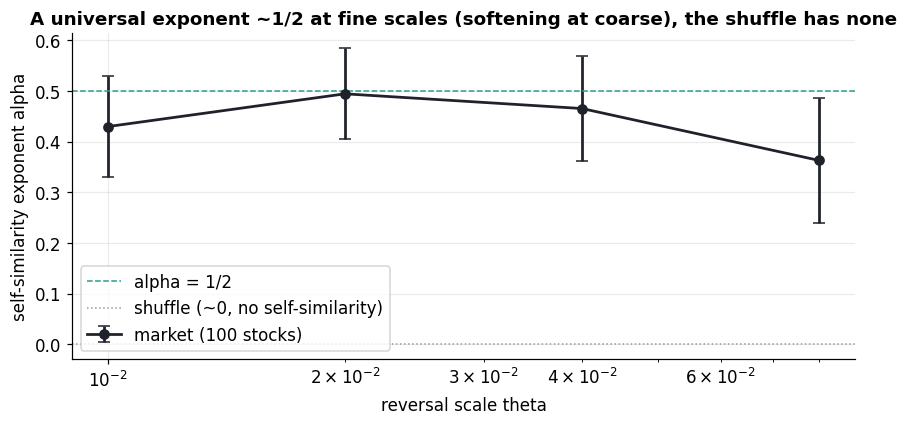

  theta=0.01: alpha = 0.430 +/- 0.099
  theta=0.02: alpha = 0.494 +/- 0.090
  theta=0.04: alpha = 0.465 +/- 0.104
  theta=0.08: alpha = 0.363 +/- 0.124


In [5]:
ths = sorted(float(k) for k in R["alpha_by_theta"])
means = [R["alpha_by_theta"][f"{t:.2f}" if f"{t:.2f}" in R["alpha_by_theta"] else str(t)]["mean"] for t in ths]
stds  = [R["alpha_by_theta"][f"{t:.2f}" if f"{t:.2f}" in R["alpha_by_theta"] else str(t)]["std"] for t in ths]
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(ths, means, yerr=stds, marker="o", color=INK, capsize=4, lw=1.8, label="market (100 stocks)")
ax.axhline(0.5, color=OK, ls="--", lw=1, label="alpha = 1/2")
ax.axhline(0.0, color="#999", ls=":", lw=1, label="shuffle (~0, no self-similarity)")
ax.set_xscale("log"); ax.set_xlabel("reversal scale theta"); ax.set_ylabel("self-similarity exponent alpha")
ax.set_title("A universal exponent ~1/2 at fine scales (softening at coarse), the shuffle has none")
ax.legend(); plt.tight_layout(); plt.show()
for t,m,sd in zip(ths,means,stds):
    print(f"  theta={t:.2f}: alpha = {m:.3f} +/- {sd:.3f}")

## The universal model, and what is and is not a law

The market clock is **one universal object**, not a hundred. It factorises as:

| ingredient | universal? | what it is |
|---|---|---|
| per-stock scale (mean gap, 4–9 days) | no — one free number per stock | just the tick rate; not physics |
| gap-distribution *shape* (lognormal) | **yes**, collapses on 100 stocks | real, **but marginal** — the shuffle shares it |
| self-similarity exponent α ≈ ½ | **yes**, tight, fine scales | the **structural** law; the shuffle has none |

So the answer to "a model per stock?" is **no**: there is a single universal law, with one
per-stock scale number. And the honest refinement your discipline demands: of the two
universal features, only the **exponent** is *structural* — the universal gap *shape* is a
marginal property a shuffle reproduces, so it must not be sold as the mechanism. The one
market-wide **constant** that survives the null is α ≈ ½.

*Reproduce:* `python level17/exp39_universal_collapse.py` writes the JSON this notebook
reads; `python notebooks/build_13.py` rebuilds the notebook.